In [116]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

In [117]:
def clr_transform(X):
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X / geom_mean)
    
    return X_clr

In [118]:
import numpy as np
import pandas as pd

def clr_transform(X):
    X_np = X.to_numpy()

    geom_mean = np.exp(np.mean(np.log(X_np), axis=1, keepdims=True))
    X_clr = np.log(X_np / geom_mean)

    return pd.DataFrame(X_clr, index=X.index, columns=X.columns)

In [119]:
data = pd.read_csv('../../DataSets/CAMDA_2026/taxonomy_relative_abundance.tsv', sep = '\t', index_col = 0)
data = data.T
metadata = pd.read_csv('../../DataSets/CAMDA_2026/metadata.tsv', sep = '\t')


In [120]:
# SE OBTIENE EL VALOR MÍNIMO 
min_value = data[data > 0].min().min()

print(min_value)


threshold = 0.9 * len(data)

# AMALGAMACIÓN DE ESPECIES POCO COMUNES
cols_otros = data.columns[(data == 0).sum() > threshold]

print(cols_otros)

data["otros"] = data[cols_otros].sum(axis=1)

data = data.drop(columns=cols_otros)

# TRATAMIENTO DE CEROS
suma_actual = data.sum(axis=1)
faltante = (100 - suma_actual).clip(lower=0)

data["otros"] += faltante


# pseudocount = min_value
pseudocount = min_value / 2
# print(pseudocount)

# Todas las columnas (incluye "otros" si existe)
cols = data.columns

# Contar cuántos ceros hay por fila en las columnas (excepto que "otros" no tenga ceros normalmente)
num_ceros = (data[cols] == 0).sum(axis=1)

# Reemplazar ceros por el pseudocount
data[cols] = data[cols].replace(0, pseudocount)

# Exceso introducido en cada fila
exceso = num_ceros * pseudocount   # Serie fila a fila

# Cantidad que se debe restar a CADA columna de esa fila
correccion = exceso / len(cols)

# Restar corrección a cada columna para mantener suma total
for c in cols:
    data[c] = data[c] - correccion

mask = (data["otros"] < 0) & (data["otros"] > -pseudocount)
data.loc[mask, "otros"] = pseudocount



0.001
Index(['Clostridium_sp_CAG_413', 'Parvimonas_micra',
       'Bifidobacterium_pseudolongum', 'Clostridium_sp_CAG_510',
       'Prevotella_intermedia', 'Peptostreptococcus_stomatis',
       'Filifactor_alocis', 'Gemella_morbillorum', 'Prevotella_sp_CAG_891',
       'Proteus_mirabilis',
       ...
       'Lachnoclostridium_sp_An169', 'Vagococcus_lutrae',
       'Lactobacillus_buchneri', 'Peptoniphilus_sp_DNF00840',
       'Treponema_porcinum', 'Candidatus_Gastranaerophilales_bacterium_HUM_9',
       'Zymomonas_mobilis', 'Helicobacter_fennelliae',
       'Enterococcus_phoeniculicola', 'Aspergillus_cristatus'],
      dtype='object', name='Species', length=932)


In [121]:
data[data.isna().any(axis=1) | (data < 0).any(axis=1)]

Species,Akkermansia_muciniphila,Escherichia_coli,Faecalibacterium_prausnitzii,Bacteroides_vulgatus,Anaerostipes_hadrus,Alistipes_putredinis,Collinsella_aerofaciens,Phascolarctobacterium_succinatutens,Desulfovibrio_piger,Coprococcus_comes,...,Streptococcus_thermophilus,Lactococcus_lactis,Haemophilus_sp_HMSC71H05,Bacteroides_faecis,Victivallis_vadensis,Butyrivibrio_crossotus,Clostridium_sp_CAG_167,Collinsella_massiliensis,Bacteroides_sp_CAG_144,otros


In [122]:
X_clr = clr_transform(data)

In [123]:
X_clr

Species,Akkermansia_muciniphila,Escherichia_coli,Faecalibacterium_prausnitzii,Bacteroides_vulgatus,Anaerostipes_hadrus,Alistipes_putredinis,Collinsella_aerofaciens,Phascolarctobacterium_succinatutens,Desulfovibrio_piger,Coprococcus_comes,...,Streptococcus_thermophilus,Lactococcus_lactis,Haemophilus_sp_HMSC71H05,Bacteroides_faecis,Victivallis_vadensis,Butyrivibrio_crossotus,Clostridium_sp_CAG_167,Collinsella_massiliensis,Bacteroides_sp_CAG_144,otros
SZAXPI003410-3,7.933972,4.472438,7.179081,3.006744,3.888362,-2.835857,1.333502,-2.835857,5.230488,4.889151,...,-2.835857,-2.835857,-2.835857,-2.835857,-2.835857,-2.835857,-2.835857,-2.835857,-2.835857,7.900144
SZAXPI003411-6,1.029425,4.331334,5.218079,3.782155,4.988556,2.808783,7.984818,3.276824,2.803460,0.661067,...,-2.845365,-2.845365,-2.845365,-2.845365,-2.845365,-2.845365,-2.845365,-2.845365,-2.845365,6.947308
SZAXPI003412-1,6.792808,5.016973,6.433297,6.232986,5.139368,5.960785,6.091549,-3.076330,-3.076330,3.062864,...,-3.076330,-3.076330,-3.076330,-3.076330,-3.076330,-3.076330,-3.076330,-3.076330,-3.076330,7.615630
SZAXPI003413-4,7.477861,3.418861,5.856166,6.811942,3.568892,6.373060,4.912012,-3.249602,-3.249602,1.632839,...,-3.249602,-3.249602,-3.249602,-3.249602,-3.249602,-3.249602,-3.249602,-3.249602,-3.249602,5.390454
SZAXPI003414-3,0.743311,6.981188,5.934998,1.757169,6.131050,1.716958,1.581139,-2.289514,-2.289514,6.604462,...,-2.289514,-2.289514,-2.289514,-2.289514,-2.289514,-2.289514,-2.289514,-2.289514,-2.289514,3.216750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CM.70_WGS,-1.541599,9.522159,8.714577,2.442719,6.281787,-1.541599,4.460650,8.860671,-1.541599,-1.541599,...,-1.541599,-1.541599,-1.541599,-1.541599,-1.541599,5.297419,-1.541599,-1.541599,-1.541599,10.949143
CM.75_WGS,-1.271378,8.432110,10.135108,-1.271378,-1.271378,-1.271378,7.914960,11.078896,6.635948,-1.271378,...,-1.271378,-1.271378,7.626820,-1.271378,-1.271378,-1.271378,-1.271378,-1.271378,-1.271378,11.429009
CM.80_WGS,-1.569068,9.349059,8.557350,-1.569068,-1.569068,-1.569068,5.821267,8.979049,6.728090,-1.569068,...,-1.569068,-1.569068,-1.569068,-1.569068,-1.569068,6.287965,-1.569068,-1.569068,-1.569068,11.227781
CM.86_WGS,-1.595633,10.900439,7.877501,-1.595633,-1.595633,-1.595633,4.716693,7.765037,6.958216,-1.595633,...,-1.595633,-1.595633,-1.595633,-1.595633,5.814842,6.988363,-1.595633,-1.595633,-1.595633,10.750579


In [131]:
metadata.columns

Index(['study_name', 'sample_id', 'subject_id', 'body_site',
       'antibiotics_current_use', 'study_condition', 'disease', 'age',
       'age_category', 'gender', 'BMI', 'country', 'non_westernized',
       'sequencing_platform', 'DNA_extraction_kit', 'PMID', 'number_reads',
       'number_bases', 'minimum_read_length', 'median_read_length',
       'NCBI_accession'],
      dtype='object')

In [134]:
metadata['antibiotics_current_use'].unique()

array(['missing: not collected', 'no', 'yes'], dtype=object)

In [136]:
metadata['age'].unique()

array(['65.0', '51.0', '53.0', '84.0', '64.0', '63.0', '69.0', '42.0',
       '62.0', '56.0', '70.0', '60.0', '54.0', '49.0', '73.0', '82.0',
       '48.0', '71.0', '72.0', '76.0', '55.0', '39.0', '58.0', '40.0',
       '59.0', '66.0', '74.0', '67.0', '45.0', '61.0', '43.0', '85.0',
       '89.0', '79.0', '83.0', '44.0', '47.0', '31.0', '78.0', '57.0',
       '68.0', '37.0', '36.0', '35.0', '46.0', '50.0', '32.0', '34.0',
       '52.0', 'missing: not collected', '38.0', '41.0', '21.0', '28.0',
       '27.0', '26.0', '29.0', '25.0', '30.0', '23.0', '24.0', '22.0',
       '19.0', '33.0', '77.0', '80.0', '81.0', '20.0', '8.0', '15.0',
       '7.0', '13.0', '17.0', '14.0', '6.0', '16.0', '10.0', '11.0',
       '9.0', '12.0', '18.0', '75.0', '87.0', '90.0'], dtype=object)

In [138]:
metadata['non_westernized'].unique()

array(['no', 'yes'], dtype=object)

In [139]:
metadata['country'].unique()

array(['USA', 'CHN', 'DNK', 'SWE', 'DEU', 'FRA', 'NOR', 'SVK', 'HUN',
       'EST', 'FIN', 'ISL', 'CMR', 'JPN'], dtype=object)

In [144]:
labels = []
for index in X_clr.index:
    if metadata[metadata['sample_id'] == index]['disease'].iloc[0] == 'healthy':
        labels.append('healthy')
    else:
        labels.append('unhealthy')

In [143]:
countries = []
for index in X_clr.index:
    countries.append(metadata[metadata['sample_id'] == index]['country'].iloc[0])

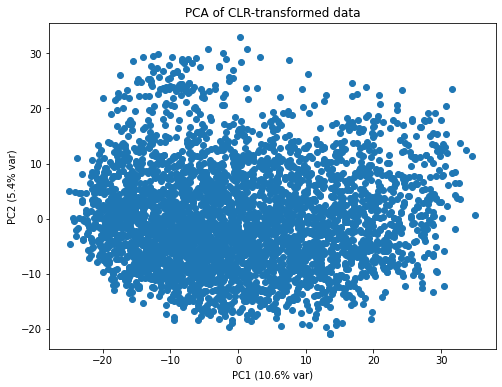

In [126]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Run PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_clr)

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(pcs[:, 0], pcs[:, 1])

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA of CLR-transformed data")

plt.show()

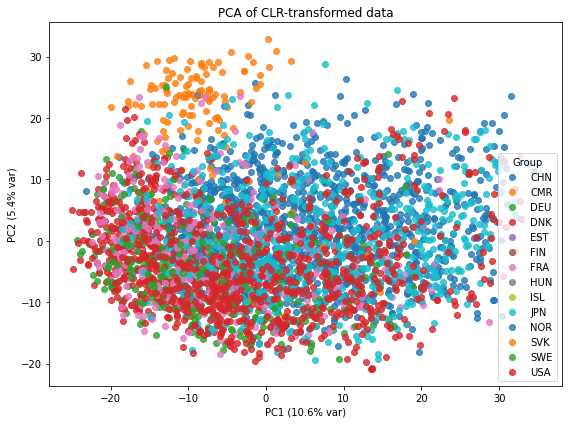

In [146]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_clr)

# Plot
plt.figure(figsize=(8, 6))

for group in np.unique(countries):
    mask = np.array(countries) == group

    plt.scatter(
        pcs[mask, 0],
        pcs[mask, 1],
        label=group,
        alpha=0.8
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA of CLR-transformed data")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

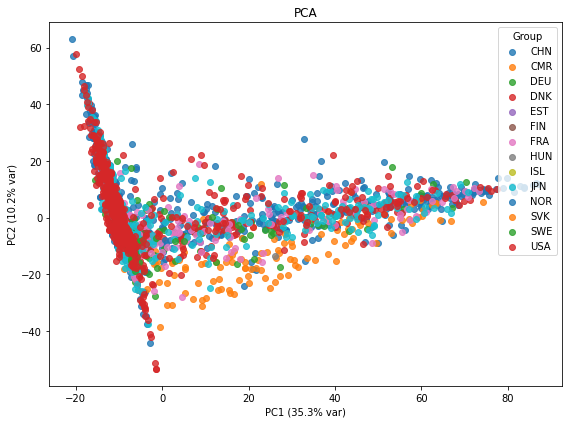

In [148]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(data)

# Plot by group
plt.figure(figsize=(8, 6))

labels = np.array(countries)

for group in np.unique(labels):
    mask = labels == group

    plt.scatter(
        pcs[mask, 0],
        pcs[mask, 1],
        label=group,
        alpha=0.8
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

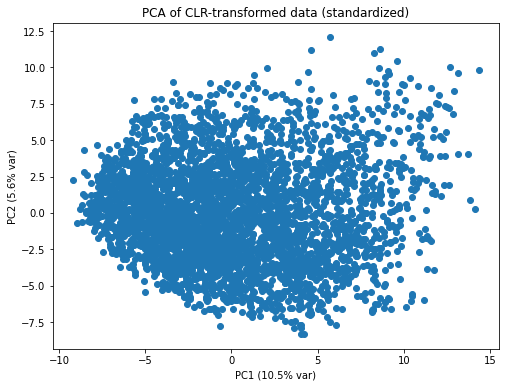

In [129]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clr)

# Run PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(pcs[:, 0], pcs[:, 1])

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA of CLR-transformed data (standardized)")

plt.show()